## Normalization 

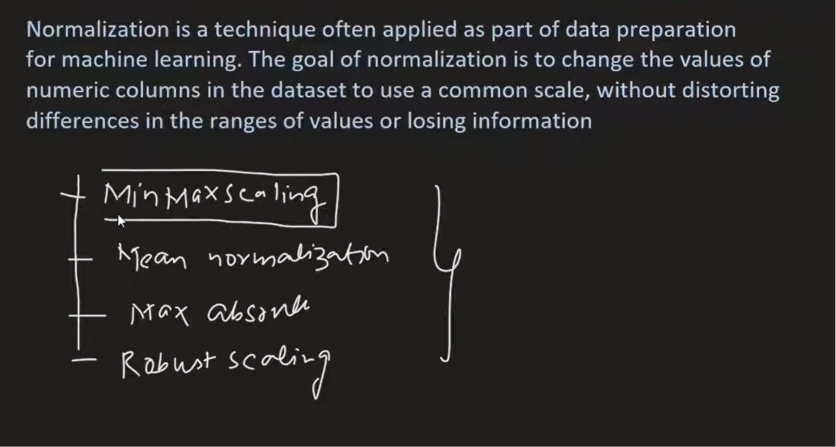

these four are types of Normalization ,and the `MinMax Scaling` is often used like 90 percent time

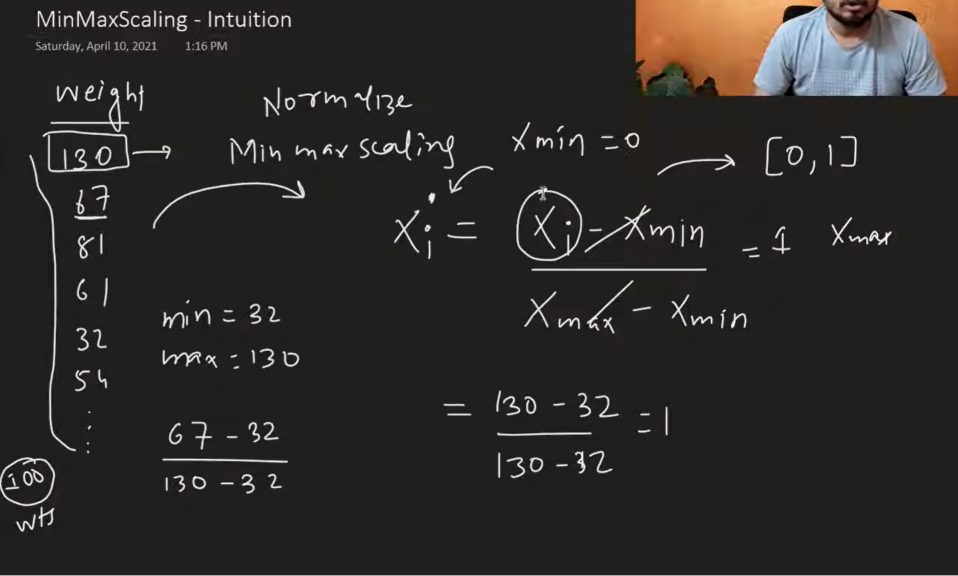

here in formula     `xmin` is the minimum of whole distribution and the `xmax` is the maximum of distribution
the range is vary [0,1]

#### Geometrical Intitution 

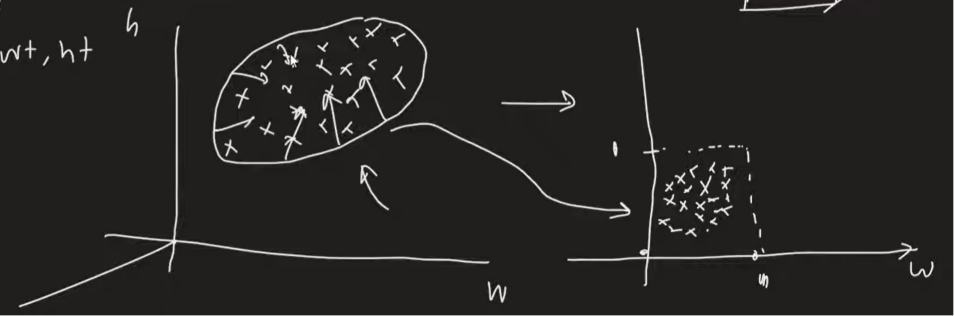

here we squeeze our data in unit sqare,rectange,cube or hypercube

### Code Example

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('dataset/wine.csv')

In [4]:
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


we dont need all column hence we take only wine,alcohal and malic acid column

In [5]:
df=df.iloc[:,:3]
df.columns=['Class label','Alcohol','Malic acid']
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [6]:
## or it can be also written as

df=pd.read_csv('dataset/wine.csv',usecols=[0,1,2])
df.columns=['Class label','Alcohol','Malic acid']

df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [7]:
# first split our dataset

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.drop('Class label',axis=1),
                                               df['Class label'],
                                               test_size=0.2,
                                               random_state=0

                                                )

random_state is used to keep the random process reproducible.

This means that every time you run your code with the same random_state, you get the same "random" result.

If you want the result to be different every time, simply don't set random_state (or set it to None).

In [8]:

x_train.head(2),x_test.head(2),y_train.head(2),y_test.head(2)

(     Alcohol  Malic acid
 161    13.69        3.26
 92     12.69        1.53,
      Alcohol  Malic acid
 54     13.74        1.67
 151    12.79        2.67,
 161    3
 92     2
 Name: Class label, dtype: int64,
 54     1
 151    3
 Name: Class label, dtype: int64)

In [9]:
## lets scale this 

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

# fit 
scaler.fit(x_train)

#transform the data

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)


# convert it into df

x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

x_train_scaled,x_test_scaled

(      Alcohol  Malic acid
 0    0.715054    0.513238
 1    0.446237    0.160896
 2    0.158602    0.254582
 3    0.637097    0.645621
 4    0.663978    0.217923
 ..        ...         ...
 137  0.212366    0.199593
 138  0.360215    0.087576
 139  0.373656    0.177189
 140  0.771505    0.191446
 141  0.841398    0.360489
 
 [142 rows x 2 columns],
      Alcohol  Malic acid
 0   0.728495    0.189409
 1   0.473118    0.393075
 2   0.360215    0.079430
 3   0.680108    0.201629
 4   0.543011    1.030550
 5   0.142473    0.266802
 6   0.814516    0.287169
 7   0.357527    0.629328
 8   0.327957    0.201629
 9   0.282258    0.221996
 10  0.626344    0.370672
 11  0.766129    0.875764
 12  0.852151    0.207739
 13  0.360215    0.067210
 14  0.685484    0.374745
 15  0.260753    0.036660
 16  0.733871    0.160896
 17  0.849462    0.173116
 18  0.432796    0.126273
 19  0.752688    0.185336
 20  0.559140    0.054990
 21  0.543011    0.185336
 22  0.594086    0.376782
 23  0.397849    0.201629

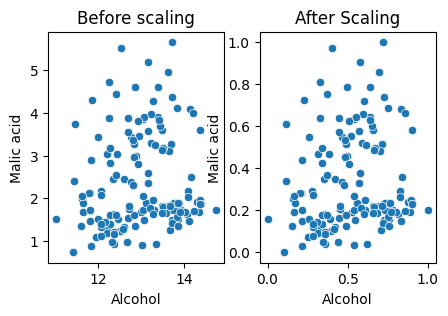

In [10]:
# lets draw scatter plot

plt.figure(figsize=(5,3))
plt.subplot(1,2,1)

sns.scatterplot(x=x_train['Alcohol'],y=x_train['Malic acid'])
plt.title('Before scaling')

plt.subplot(1,2,2)
sns.scatterplot(x=x_train_scaled['Alcohol'],y=x_train_scaled['Malic acid'])
plt.title('After Scaling')

plt.show()

In [11]:
x_train.describe()

,Alcohol,Malic acid
count,142.000000,142.000000
mean,12.984859,2.372606
std,0.807175,1.115360
min,11.030000,0.740000
25%,12.347500,1.602500
50%,13.040000,1.895000
75%,13.637500,3.222500
max,14.750000,5.650000


In [12]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,142.000000,142.000000
mean,0.525500,0.332506
std,0.216983,0.227161
min,0.000000,0.000000
25%,0.354167,0.175662
50%,0.540323,0.235234
75%,0.700941,0.505601
max,1.000000,1.000000


as we can see that the min and max after scaling is 0 and 1 respectively

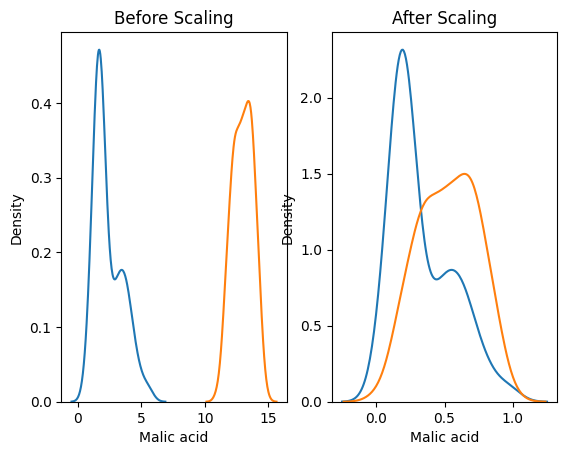

In [13]:
# lets plot kde graph and see what is the differece

plt.subplot(1,2,1)
sns.kdeplot(x_train['Malic acid'])
sns.kdeplot(x_train['Alcohol'])
plt.title('Before Scaling')

plt.subplot(1,2,2)
sns.kdeplot(x_train_scaled['Malic acid'])
sns.kdeplot(x_train_scaled['Alcohol'])
plt.title('After Scaling')

plt.show()

as we can see that before scalig the distance far so we cant make comparison as that whcih plot is up and down  but 
it can be seen that after scaling it can easily be comparable that which graph is up and down 

### lets draw distribution graph

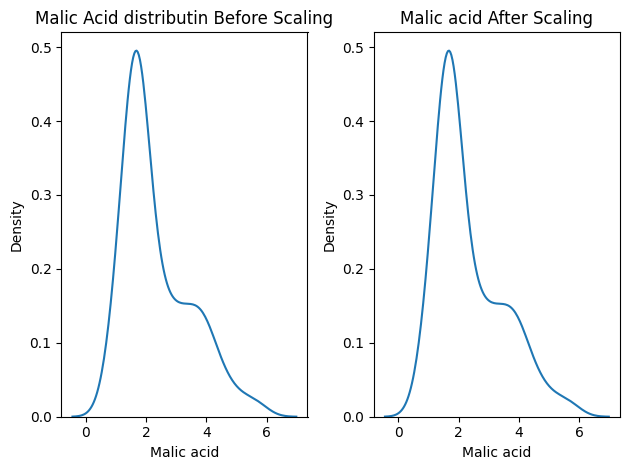

In [17]:
plt.subplot(1,2,1)
sns.kdeplot(df['Malic acid'])
plt.title('Malic Acid distributin Before Scaling')

plt.subplot(1,2,2)
sns.kdeplot(df['Malic acid'])
plt.title('Malic acid After Scaling')

plt.tight_layout()  # used for proper spacing btweeen the two graph
plt.show()

it is not necessary that the graph is always be same there can be slightly difference in  graph

##### in the min max scaling we keep everything in 0 to 1 so outlier get squeezed hence only this is the disadvantage of minmax scaling otherwise 90 percetn times we use this method

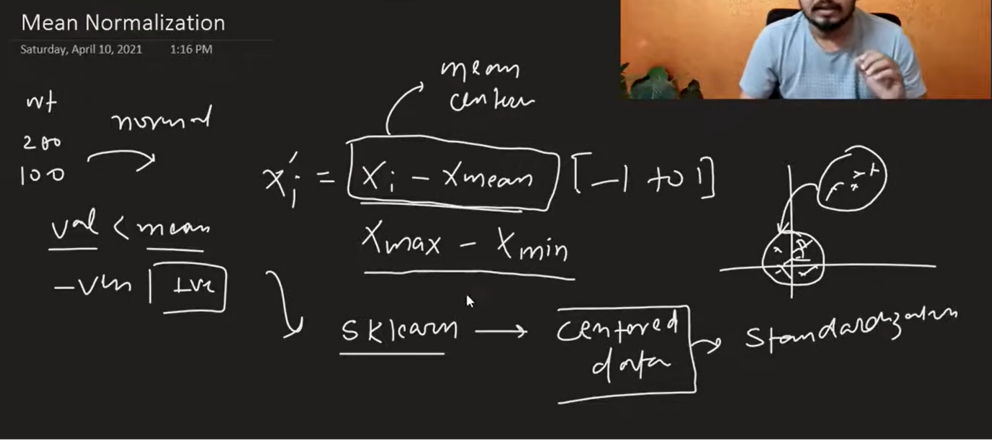

this is used when we need centred data 

lets undersatnd the Image


if val<mean then the value is -ve otherwise +ve value  (Xi-Xmean)  is used for mean center  and (Xmax-Xmin)  is used for scaling 

in sklearn dont have library for this you have to write code by own so people use standardization instead of this

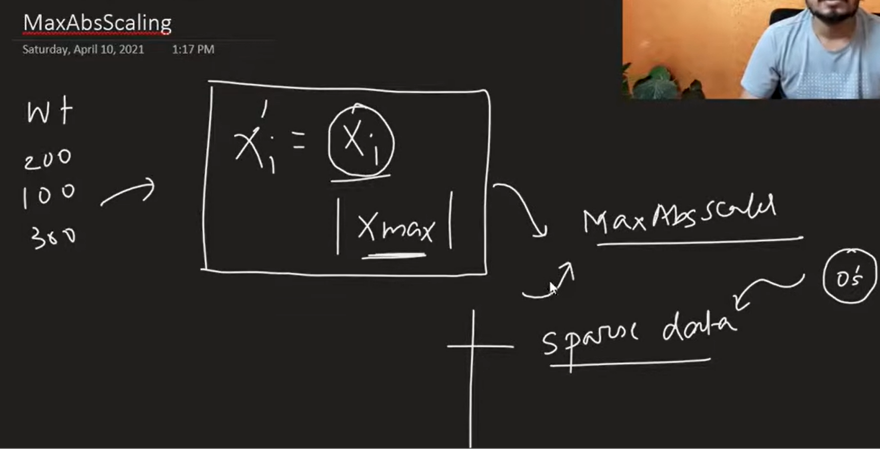


MaxAbsScaling is maxabsolute scaling it is used when the number of zeros is more that is in sparse data


in sklearn there is class named MaxAbs scaler inside sklearn preprocessing module

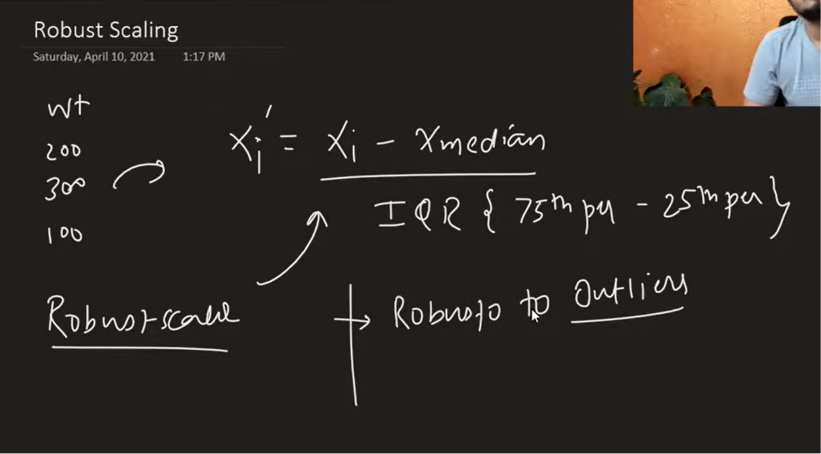

Robust scaling is used when a lot of outliers in our data   

there is class name `Robust scaller `  inside sklearn preprocessing module

iqr means inter quarterile range

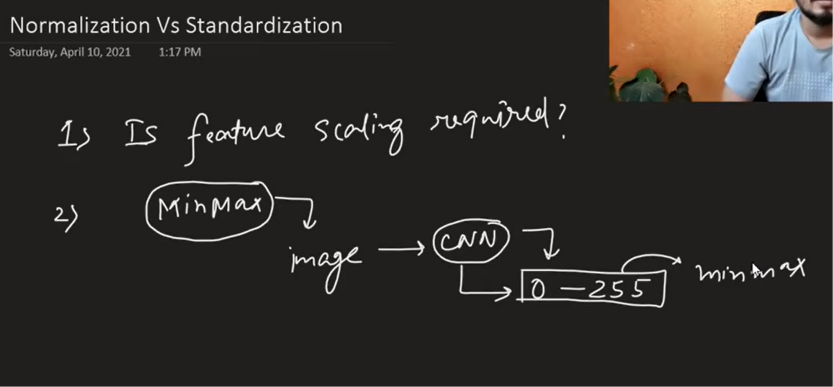

the first question is 

1. is feature scaling needded  ? as if we use decision treee algo then we dont need to do scaling 

2. maximum time we use standardization it gives generally good result

3. minmax is used in cnn or when u have knowledge about then min and max of the dataset it is used in cnn for image preprocessing

at last you have to run all method of scaling and observe which performs better in differet dataset